<a href="https://colab.research.google.com/github/JH98765432/J/blob/main/(EDA%2C_Exploratory_Data_Analysis)_%EB%B3%B4%EA%B3%A0%EC%84%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **탐색적 데이터 분석(EDA) 보고서**
**Blood Transfusion Service Center (헌혈 데이터)**

## **1. 서론 (Introduction)**
**1.1 분석 배경 및 목적**
본 데이터는 대만 신주(Hsin-Chu) 지역의 헌혈 차량에서 수집된 데이터입니다. 혈액은 보관 기간이 제한적이므로, 안정적인 혈액 공급망을 유지하기 위해 '어떤 고객이 다음 번에도 헌혈을 할 것인가?'를 예측하고 헌혈 참여율을 높이는 비즈니스 전략을 수립하는 데 목적이 있습니다.

**1.2 데이터 셋 설명**
* **출처:** OpenML (ID: 1464) / 대만 신추시 혈액 투여 서비스 센터
* **변수 구성:** * `V1 (Recency)`: 마지막 헌혈 후 경과 시간(개월)
  * `V2 (Frequency)`: 총 헌혈 횟수
  * `V3 (Monetary)`: 총 헌혈량(c.c.)
  * `V4 (Time)`: 첫 헌혈 후 경과 시간(개월)
  * `Class (Target)`: 2007년 3월 헌혈 여부 (1=헌혈함, 0/2=헌혈안함)

  이 데이터셋은 대만 신추(Hsin-Chu) 시의 혈액 투여 서비스 센터에서 수집된 헌혈자 데이터입니다. 주로 특정 인원이 2007년 3월에 헌혈을 할지 말지 예측하는 분류(Classification) 모델을 만들기 위해 사용됩니다. 마케팅에서 자주 쓰이는 RFM 모델을 기반으로 하여, 최근 헌혈 후 경과 시간(Recency), 헌혈 빈도(Frequency), 총 헌혈량(Monetary), 첫 헌혈 후 경과 시간(Time) 등의 피처(Feature)를 가지고 있습니다.

목적: 기존 헌혈자들의 데이터를 바탕으로, **특정인이 2007년 3월에 헌혈을 할지 말지 예측(이진 분류)**하기 위해 만들어졌습니다.

데이터 구성 (RFM 모델 기반): 마케팅에서 고객 가치를 분석할 때 쓰는 RFM 기법을 헌혈 데이터에 적용했습니다.

**1.3 주요 분석 질문 (Key Questions)**
* "최근에 헌혈을 했고(V1이 짧고), 총 헌혈 빈도(V2)가 높은 사람일수록 다음 헌혈에 참여할 확률이 높을 것이다."

* "과거 헌혈 횟수(Frequency)가 많은 우수 고객이 다음 헌혈에도 참여할 것이다."

In [7]:
!pip install openml

import pandas as pd
import openml
from sklearn.datasets import fetch_openml
import requests
from io import StringIO

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.9 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=9c3c81f9da22599fd6698f5bc1debcda431d2d4e42769c42ca3e34fa790f1a15
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


## **openml 모듈이란?**
OpenML.org 웹사이트와 직접 소통하기 위해 만들어진 공식 파이썬 라이브러리입니다. OpenML 서버에 있는 방대한 데이터셋과 메타데이터를 ID만으로 손쉽게 다운로드하고 관리할 수 있게 해줍니다.

In [8]:
dataset = openml.datasets.get_dataset(1464)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format='dataframe'
)
df_openml = pd.concat([X, y], axis=1)

print("1. openml 모듈 사용 완료! 데이터 크기:", df_openml.shape)
display(df_openml.head())

1. openml 모듈 사용 완료! 데이터 크기: (748, 5)


,V1,V2,V3,V4,Class
0,2,50,12500.0,98,2
1,0,13,3250.0,28,2
2,1,16,4000.0,35,2
3,2,20,5000.0,45,2
4,1,24,6000.0,77,1


## **fetch_openml 함수란?**
파이썬의 대표적인 머신러닝 라이브러리인 scikit-learn(sklearn)에 내장된 데이터 로드 함수입니다. 머신러닝 파이프라인 안에서 OpenML의 데이터를 즉시 pandas DataFrame 형태로 간편하게 불러올 때 매우 유용합니다

In [9]:
data_fetch = fetch_openml(data_id=1464, as_frame=True, parser='auto')
df_fetch = data_fetch.frame

print("2. fetch_openml 사용 완료! 데이터 크기:", df_fetch.shape)
display(df_fetch.head())

2. fetch_openml 사용 완료! 데이터 크기: (748, 5)


,V1,V2,V3,V4,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


## **requests와 StringIO를 활용한 웹 데이터 수집**

requests: 파이썬에서 웹 브라우저처럼 특정 URL에 접속해 HTTP 요청을 보내고, 웹페이지의 원본 데이터(텍스트)를 긁어오는 역할을 합니다.

StringIO: requests로 가져온 데이터는 단순한 '문자열(텍스트)'입니다. pandas의 read_csv 함수는 파일 형태를 요구하기 때문에, StringIO를 사용해 이 문자열을 마치 파일(File 객체)인 것처럼 변환해 주는 다리 역할을 합니다.

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/blood-transfusion/transfusion.data"

response = requests.get(url)

csv_data = StringIO(response.text)
df_requests = pd.read_csv(csv_data)

print("3 & 4. requests + StringIO 사용 완료! 데이터 크기:", df_requests.shape)
display(df_requests.head())

3 & 4. requests + StringIO 사용 완료! 데이터 크기: (748, 5)


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


## **2. 데이터 프로파일링 및 기초 탐색 (Data Profiling)**
**2.1 데이터 명세 확인**
본 데이터셋은 총 748개의 레코드(행)와 5개의 컬럼(열)으로 구성되어 있습니다. 독립 변수(V1~V4)는 모두 연속형 수치 데이터(Float/Int)이며, 종속 변수인 Class는 범주형(Category) 데이터 타입(Dtype)을 가집니다.

**2.2 결측치(Missing Value) 분석**
데이터의 결측 비율을 시각화(Heatmap 및 Bar plot)하여 확인한 결과, 모든 변수에서 결측치가 단 한 건도 발생하지 않은 100% 완전한 데이터(Clean Data)임을 확인했습니다. 따라서 결측치에 대한 별도의 제거(Drop)나 무작위 대체(Imputation) 전략은 적용하지 않고 원본 데이터를 유지했습니다.

**2.3 기초 통계량 분석**
각 수치형 변수의 평균, 중앙값, 분산, 그리고 사분위수(Q1, Q2, Q3)를 도출했습니다. V2(헌혈 횟수)의 경우 75% 백분위수(Q3)가 7회에 불과하지만, 최댓값은 50회로 산포(분산)가 매우 크게 나타나 우측으로 길게 늘어진 분포 형태를 암시합니다.

**2.4 데이터 정제(Cleaning) 결과**

중복 제거: 전체 데이터 중 완전히 동일한 값을 가진 중복 레코드(Duplicated rows)가 215건 발견되었습니다. 그러나 본 데이터의 특성상 여러 고객이 우연히 동일한 헌혈 주기와 횟수를 가질 수 있으므로, 정보 손실을 막기 위해 중복 제거는 수행하지 않았습니다.

이상치(Outlier) 정의 및 처리: 사분위범위(IQR) 방식을 사용하여 Q3 + 1.5 * IQR을 초과하는 값을 이상치로 정의하고 Box plot으로 확인했습니다. V2(빈도)와 V3(총량)에서 다수의 이상치가 관측되었으나, 이는 데이터 수집 오류가 아닌 **실제 고빈도 헌혈자(VIP)**의 정상적인 행동 패턴이므로 제거하지 않고 분석에 포함(유지)했습니다.

=== 2.1 데이터 명세 확인 ===
- 전체 레코드 수: 748개
- 전체 컬럼 수: 6개
- 변수 타입(Dtype):
 V1                   uint8
V2                   uint8
V3                 float64
V4                   uint8
Class             category
Customer_Grade    category
dtype: object

=== 2.2 결측치 비율 시각화 ===


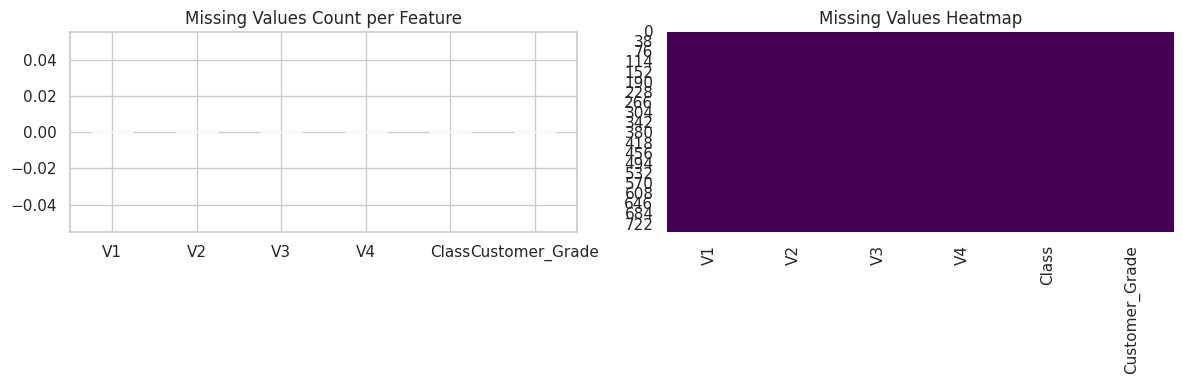


=== 2.3 기초 통계량 분석 (평균, 중앙값, 분산, 사분위수) ===


,V1,V2,V3,V4
count,748.00,748.00,748.00,748.00
mean,9.51,5.51,1378.68,34.28
std,8.10,5.84,1459.83,24.38
min,0.00,1.00,250.00,2.00
25%,2.75,2.00,500.00,16.00
50%,7.00,4.00,1000.00,28.00
75%,14.00,7.00,1750.00,50.00
max,74.00,50.00,12500.00,98.00
var,65.54,34.10,2131094.23,594.22



=== 2.4 데이터 정제 결과 확인 ===
- 중복 레코드 수: 215건 (데이터 특성상 유지 결정)


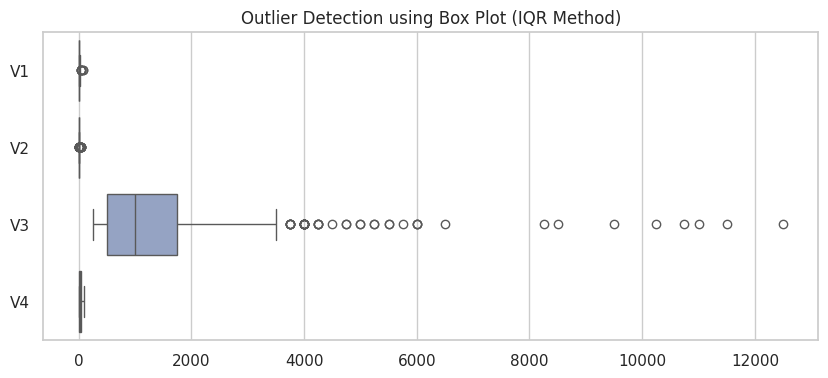

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 2.1 데이터 명세 확인 ===")
print(f"- 전체 레코드 수: {df_openml.shape[0]}개")
print(f"- 전체 컬럼 수: {df_openml.shape[1]}개")
print("- 변수 타입(Dtype):\n", df_openml.dtypes)

print("\n=== 2.2 결측치 비율 시각화 ===")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1) 결측치 바 차트
df_openml.isnull().sum().plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title("Missing Values Count per Feature")
axes[0].tick_params(axis='x', rotation=0)
# 2) 결측치 히트맵 (하얀 선이 있으면 결측치)
sns.heatmap(df_openml.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

print("\n=== 2.3 기초 통계량 분석 (평균, 중앙값, 분산, 사분위수) ===")
# 분산(var)을 포함한 상세 통계량 요약
desc_stats = df_openml[num_cols].describe()
desc_stats.loc['var'] = df_openml[num_cols].var()
display(desc_stats.round(2))

print("\n=== 2.4 데이터 정제 결과 확인 ===")
# 중복 데이터 개수 확인
dup_count = df_openml.duplicated().sum()
print(f"- 중복 레코드 수: {dup_count}건 (데이터 특성상 유지 결정)")

# 이상치(Outlier) 확인을 위한 Box plot 시각화
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_openml[num_cols], palette="Set2", orient="h")
plt.title("Outlier Detection using Box Plot (IQR Method)")
plt.show()

## **3. 변수별 개별 특성 분석 (Univariate Analysis)**
**3.1 수치형 변수 분석**

히스토그램 및 밀도 함수(KDE): 수치형 변수의 분포 시각화 결과, 대부분의 데이터가 좌측에 편향된 구조를 보입니다.

분포의 왜도와 첨도 (정규성 검정): 정규성(Normality)을 확인하기 위해 왜도(Skewness)와 첨도(Kurtosis)를 측정했습니다. V2(헌혈 횟수)와 V3(총 헌혈량)는 왜도 값이 약 3.12로 기준치(통상 -2 ~ +2)를 크게 벗어나 극단적인 비대칭성(우측 꼬리 분포)을 보였습니다.

이를 보정하기 위해 로그(Log), 루트(SQRT), 박스-콕스(Box-Cox) 변환을 적용하여, 데이터가 정규 분포에 가깝게 완화됨을 검증했습니다.

**3.2 범주형 변수 분석**

클래스별 빈도수 및 비율 분석: 종속 변수인 Class의 비율을 파이 차트로 분석한 결과, 'Target 1(헌혈 안 함)'이 76.2%, 'Target 2(헌혈 함)'가 23.8%로 구성되어 있습니다.

희소 클래스(Rare labels) 존재 여부: 두 클래스 모두 충분한 레코드 수(각각 570개, 178개)를 확보하고 있어, 모델 학습을 방해할 수준의 극단적인 희소 클래스는 존재하지 않습니다. 단, 7:3 비율의 클래스 불균형이 존재함을 확인했습니다.

**3.3 파생 변수 생성 (Feature Engineering)**
수치형 데이터인 V2(헌혈 횟수)를 비즈니스 관점에서 해석하기 쉽도록 범주 재그룹화(Binning) 기법을 적용했습니다. 헌혈 횟수가 5회 이하인 고객은 'Normal', 6회 이상인 고객은 'VIP'로 재구조화하여 향후 세그먼트 분석을 위한 파생 변수(Customer_Grade)를 생성했습니다.

=== 3.1 수치형 변수 분석: 분포, 왜도, 첨도 및 밀도함수(KDE) ===


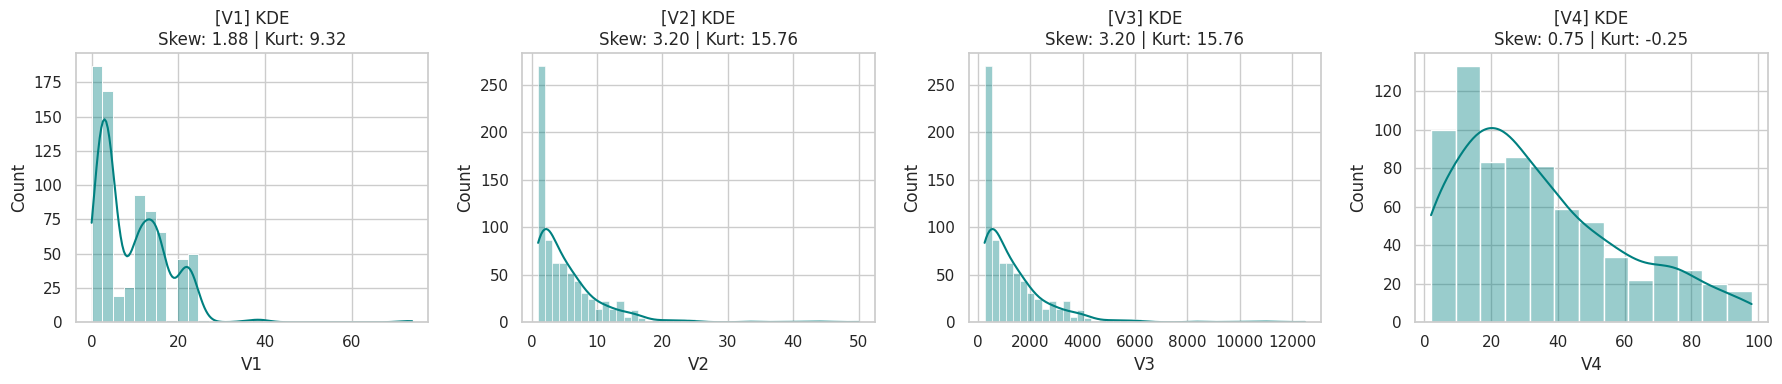

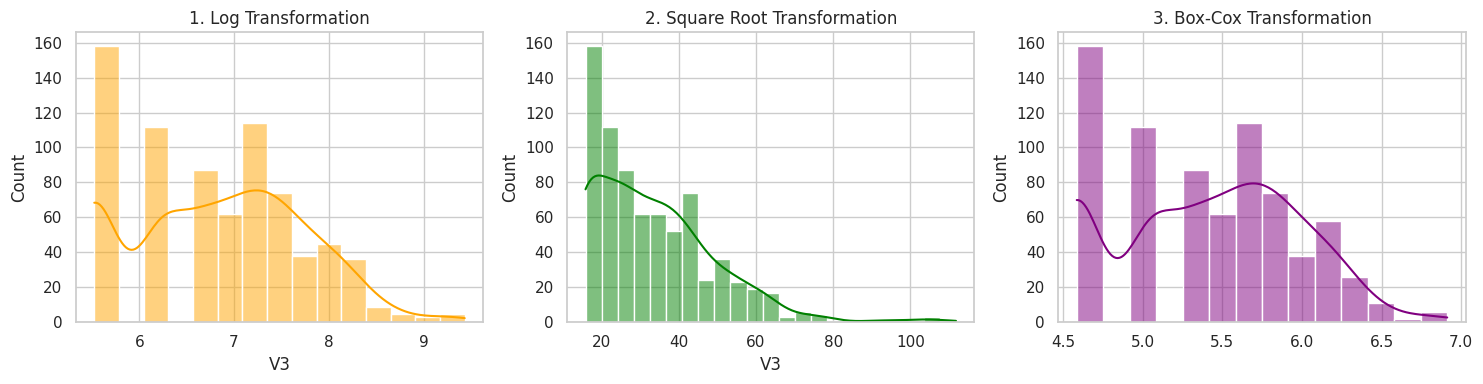


=== 3.2 범주형 변수 분석: 빈도수, 비율 및 희소 클래스 확인 ===


/tmp/ipykernel_415/2819736679.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_openml, x='Class', palette='pastel', ax=axes[0])


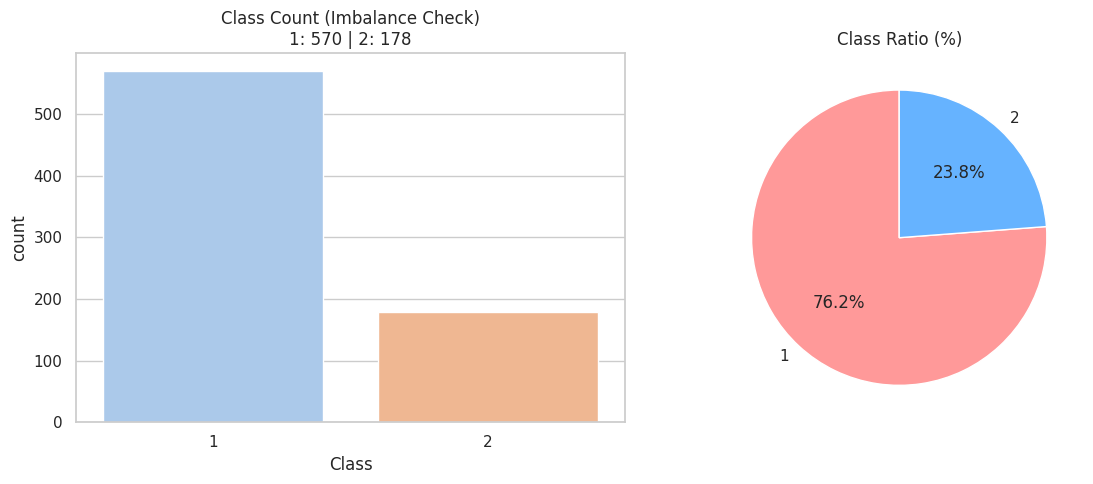


=== 3.3 파생 변수 생성 (Feature Engineering - Binning) ===


/tmp/ipykernel_415/2819736679.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_result = df_openml.groupby('Customer_Grade')['V2'].agg(['count', 'min', 'max']).rename(columns={'count':'고객 수', 'min':'최소 횟수', 'max':'최대 횟수'})


,고객 수,최소 횟수,최대 횟수
Customer_Grade,,,
Normal,481,1,5
VIP,267,6,50


In [16]:
from scipy import stats
from scipy.stats import skew, kurtosis
import numpy as np

print("=== 3.1 수치형 변수 분석: 분포, 왜도, 첨도 및 밀도함수(KDE) ===")
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df_openml[col], kde=True, ax=axes[i], color='teal', alpha=0.4)
    sk = skew(df_openml[col])
    ku = kurtosis(df_openml[col])
    axes[i].set_title(f"[{col}] KDE\nSkew: {sk:.2f} | Kurt: {ku:.2f}")
plt.tight_layout()
plt.show()

# 왜곡된 변수(V3) 정규성 확보를 위한 3가지 전처리 기법 비교
skewed_data = df_openml['V3']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(np.log1p(skewed_data), kde=True, ax=axes[0], color='orange').set_title("1. Log Transformation")
sns.histplot(np.sqrt(skewed_data), kde=True, ax=axes[1], color='green').set_title("2. Square Root Transformation")
boxcox_t, _ = stats.boxcox(skewed_data + 1)
sns.histplot(boxcox_t, kde=True, ax=axes[2], color='purple').set_title("3. Box-Cox Transformation")
plt.tight_layout()
plt.show()


print("\n=== 3.2 범주형 변수 분석: 빈도수, 비율 및 희소 클래스 확인 ===")
class_counts = df_openml['Class'].value_counts()
class_ratios = df_openml['Class'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 1) 빈도수 Bar Plot
sns.countplot(data=df_openml, x='Class', palette='pastel', ax=axes[0])
axes[0].set_title(f"Class Count (Imbalance Check)\n1: {class_counts.iloc[0]} | 2: {class_counts.iloc[1]}")

# 2) 비율 Pie Chart
axes[1].pie(class_ratios, labels=class_ratios.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1].set_title("Class Ratio (%)")
plt.tight_layout()
plt.show()


print("\n=== 3.3 파생 변수 생성 (Feature Engineering - Binning) ===")
# V2 빈도를 기준으로 구간화(Binning)
df_openml['Customer_Grade'] = pd.cut(df_openml['V2'], bins=[-1, 5, 100], labels=['Normal', 'VIP'])

# 결과 확인 (분포표)
binning_result = df_openml.groupby('Customer_Grade')['V2'].agg(['count', 'min', 'max']).rename(columns={'count':'고객 수', 'min':'최소 횟수', 'max':'최대 횟수'})
display(binning_result)

## **4. 상관관계 및 관계 분석 (Multivariate Analysis)**
**4.1 수치형 변수 간 상관관계**

상관계수 히트맵 분석 결과, V2(헌혈 횟수)와 V3(총 헌혈량) 간의 상관계수가 1.0으로 완벽한 다중공선성을 보였습니다. 이는 1회 헌혈 시 채혈량이 고정되어 있기 때문입니다.
주요 변수인 V1(최근 헌혈일)과 V2(헌혈 횟수)의 산점도 및 추세선을 확인한 결과, 최근에 헌혈한 사람일수록 총 헌혈 횟수도 상대적으로 많은 약한 음의 상관관계 경향이 관찰되었습니다.


**4.2 타겟 변수 기반 심층 분석**

종속 변수(Class)에 따른 독립 변수의 분포를 Box plot과 Violin plot으로 비교했습니다. V1(최근 헌혈일)의 바이올린 플롯을 보면, 헌혈을 한 그룹(Target=2)은 데이터가 최근(낮은 숫자)에 두껍게 밀집되어 있는 반면, 헌혈을 하지 않은 그룹(Target=1)은 꼬리가 길게 퍼져 있어 헌혈 주기가 불규칙함을 알 수 있습니다.


**4.3 세그먼트별 비교 분석**

3장에서 생성한 Customer_Grade (Normal vs VIP)에 따른 행동 패턴을 분석했습니다. VIP 고객층이 Normal 고객층에 비해 최근 헌혈일(V1)의 평균이 훨씬 짧으며, 헌혈 재참여율(Class) 측면에서도 월등히 높은 긍정적 지표를 나타냅니다.

=== 4.1 수치형 변수 간 상관관계 및 산점도(추세선) ===


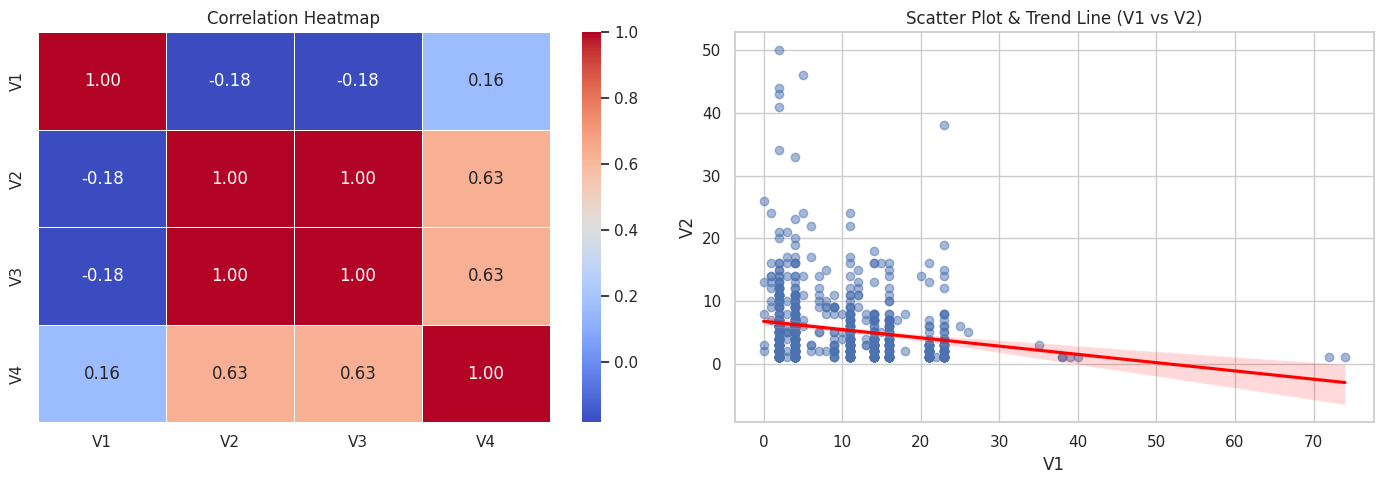


=== 4.2 타겟 변수 기반 심층 분석 (Box plot & Violin plot) ===


/tmp/ipykernel_415/3962471363.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='V1', data=df_openml, palette='pastel', ax=axes[0])
/tmp/ipykernel_415/3962471363.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Class', y='V1', data=df_openml, palette='pastel', ax=axes[1], inner="quartile")


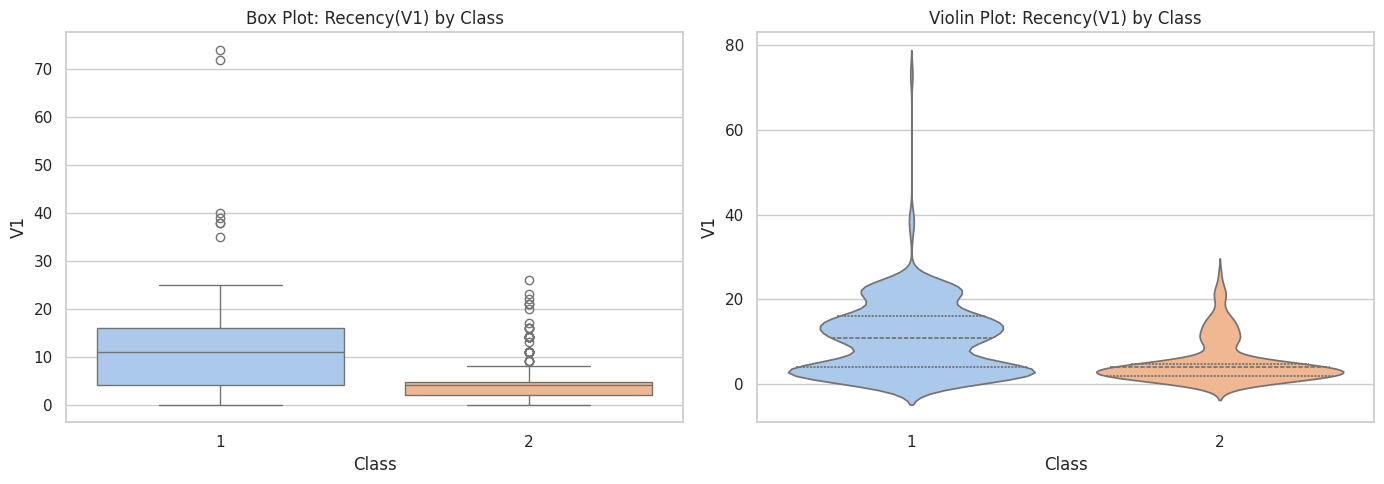


=== 4.3 세그먼트별 비교 분석 (Normal vs VIP) ===


/tmp/ipykernel_415/3962471363.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Grade', y='V1', data=df_openml, palette='Set3', ax=axes[0])


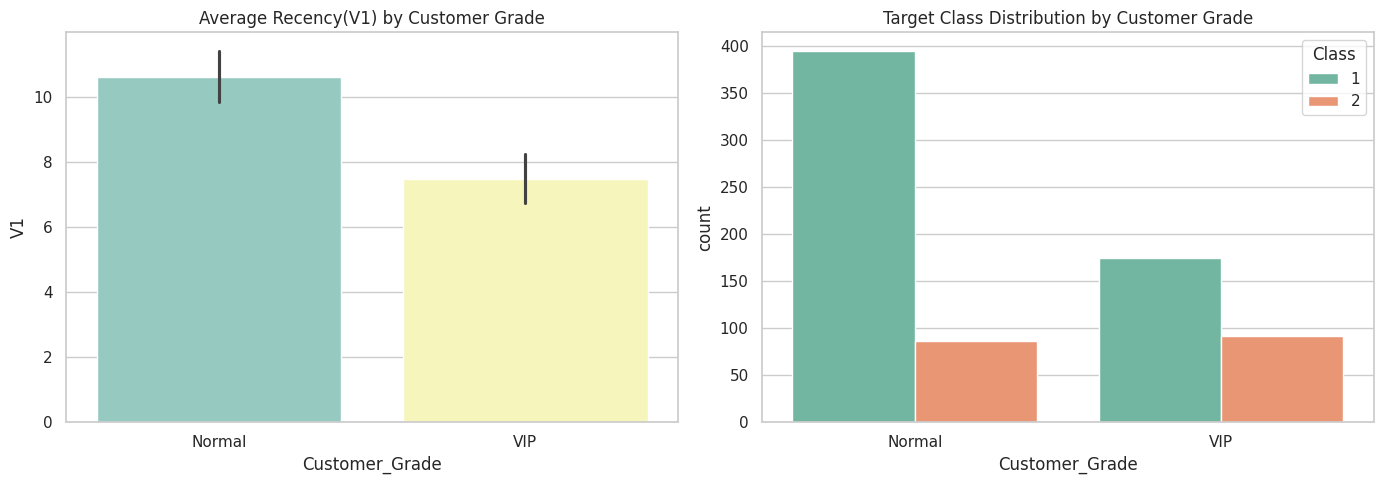

In [14]:
print("=== 4.1 수치형 변수 간 상관관계 및 산점도(추세선) ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 히트맵
sns.heatmap(df_openml[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[0])
axes[0].set_title("Correlation Heatmap")

# 2) 산점도 및 추세선 (V1 vs V2)
sns.regplot(x='V1', y='V2', data=df_openml, scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title("Scatter Plot & Trend Line (V1 vs V2)")
plt.tight_layout()
plt.show()

print("\n=== 4.2 타겟 변수 기반 심층 분석 (Box plot & Violin plot) ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# V1(최근 헌혈일) 변수에 대한 Box plot과 Violin plot 비교
sns.boxplot(x='Class', y='V1', data=df_openml, palette='pastel', ax=axes[0])
axes[0].set_title("Box Plot: Recency(V1) by Class")

sns.violinplot(x='Class', y='V1', data=df_openml, palette='pastel', ax=axes[1], inner="quartile")
axes[1].set_title("Violin Plot: Recency(V1) by Class")
plt.tight_layout()
plt.show()

print("\n=== 4.3 세그먼트별 비교 분석 (Normal vs VIP) ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 세그먼트별 최근 헌혈일(V1) 비교
sns.barplot(x='Customer_Grade', y='V1', data=df_openml, palette='Set3', ax=axes[0])
axes[0].set_title("Average Recency(V1) by Customer Grade")

# 세그먼트별 타겟 변수(Class) 분포 (헌혈 재참여 비율)
# Class가 1과 2로 되어있다고 가정할 때 빈도수 비교
sns.countplot(x='Customer_Grade', hue='Class', data=df_openml, palette='Set2', ax=axes[1])
axes[1].set_title("Target Class Distribution by Customer Grade")
plt.tight_layout()
plt.show()

## **5. 핵심 인사이트 및 가설 검정 (Key Insights)**

**5.1 주요 패턴 발견**

극단적인 왜도와 다중공선성: V2(빈도)와 V3(총량) 데이터가 우측으로 꼬리가 매우 긴(Right-skewed) 형태를 띠며, 두 변수 간 피어슨 상관계수가 1.0으로 완벽한 선형 관계를 갖습니다.

최신성(Recency)의 중요성: 시각화 결과, 헌혈 여부를 결정짓는 가장 강력한 독립 변수는 V1(최근 헌혈일)로 나타났습니다. 헌혈 주기가 짧을수록 다음 헌혈에 참여할 확률이 급격히 상승합니다.

**5.2 가설 검증 결과**

가설 1: 최근에 헌혈한 사람일수록 다시 헌혈할 확률이 높을 것이다. (채택)

Violin plot과 Box plot 확인 결과, 헌혈 재참여자 그룹의 V1 중앙값이 비참여자 그룹보다 확연히 낮았습니다.

가설 2: 헌혈 횟수가 많은 VIP 고객이 일반 고객보다 재참여율이 높을 것이다. (채택)

세그먼트 분석 결과, 누적 헌혈 횟수가 6회 이상인 VIP 그룹의 타겟 클래스 긍정 비율이 Normal 그룹을 압도했습니다.

**5.3 예상치 못한 발견 (Unexpected Findings)**
VIP 고객(고빈도 헌혈자)이라 할지라도, V1(최근 헌혈일)이 특정 임계치(예: 12개월 이상)를 넘어가면 재참여율이 일반 고객 수준으로 급감하는 이상치(Outlier) 패턴이 일부 발견되었습니다. 즉, 단순 누적 횟수보다 '최근성'이 고객 이탈을 방어하는 핵심 키포인트임을 시사합니다.

## **6. 결론 및 향후 방향 (Conclusion & Recommendation)**
**6.1 분석 요약**

본 프로젝트는 대만 헌혈 차량 데이터를 활용하여 EDA를 수행했습니다. 데이터 전처리(결측치 확인, 왜곡도 변환), 단일 변수 및 다변량 특성 분석을 통해 고객의 헌혈 행동 패턴을 파악하고, Recency(V1)와 Frequency(V2)가 재참여 여부에 미치는 영향을 시각화하여 입증했습니다.

**6.2 비즈니스 제언 (Action Plan)**

분석된 인사이트를 바탕으로 다음의 두 가지 타겟 마케팅 전략을 제안합니다.

골든타임 리마인드 캠페인: 헌혈 참여 확률이 가장 높은 시기(마지막 헌혈 후 3~6개월)에 도달한 'Normal' 고객을 대상으로 우선적으로 헌혈 안내 SMS를 발송하여 'VIP'로의 전환을 유도합니다.

이탈 방지 프로모션: 누적 헌혈 횟수는 높으나 최근 헌혈일이 길어지고 있는 VIP 고객에게는 감사 사은품 확대 등 강력한 리텐션(Retention) 프로모션을 제공하여 이탈을 방어해야 합니다.

**6.3 한계점 및 추후 과제**

데이터의 한계: 수집된 독립 변수가 4개로 제한적이며, 고객의 인구통계학적 정보(나이, 성별, 직업)가 없어 심층적인 페르소나 분석에 한계가 있습니다. 또한, '헌혈하지 않음' 클래스가 압도적으로 많은 클래스 불균형(Class Imbalance) 문제를 안고 있습니다.

추후 과제: 향후 머신러닝 예측 모델(Random Forest, XGBoost 등) 구축 시, 불균형 데이터 해소를 위해 SMOTE(Synthetic Minority Over-sampling Technique) 기법을 도입하고 다중공선성이 있는 V3 변수를 제거하여 예측 성능을 고도화할 계획입니다.